# Sleep Health and Lifestyle — Descriptive Statistics Analysis

**Goal:** produce the descriptive-statistics evidence (central tendency, spread, shape, distribution plots) needed for the four results:
1. Data Description
2. Typical Amount of Physical Activity
3. Number of Daily Steps
4. Distribution of Heart Rates

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("sleep_data.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

df.head()

Shape: 374 rows, 13 columns



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 1. Data Description

### 1.1 Variable classification

Before computing anything, each column needs to be classified — mean/median/mode and skewness are only meaningful for the right variable types.

| Variable | Type | Nominal / Ordinal / Continuous / Discrete | Reasoning |
|---|---|---|---|
| Person ID | Categorical | Nominal | Identifier only — arithmetic on it is meaningless |
| Gender | Categorical | Nominal | Two unordered labels |
| Age | Numeric | Discrete (treated as continuous) | Whole years, but wide enough range to summarize with mean/std like a continuous variable |
| Occupation | Categorical | Nominal | 11 unordered job titles |
| Sleep Duration | Numeric | Continuous | Measured in hours to one decimal |
| Quality of Sleep | Numeric (rating) | **Ordinal** | 1–9 self-report scale — order matters, but the gap between 6 and 7 isn't guaranteed equal to the gap between 7 and 8 |
| Physical Activity Level | Numeric | Continuous | Minutes/day, effectively continuous |
| Stress Level | Numeric (rating) | **Ordinal** | Same reasoning as Quality of Sleep — a bounded self-report scale |
| BMI Category | Categorical | **Ordinal** | Normal < Overweight < Obese has a real clinical order, even though it's stored as text |
| Blood Pressure | Text (compound) | N/A until split | Stored as `"systolic/diastolic"` — not usable numerically until parsed into two columns. |
| Heart Rate | Numeric | Continuous (discrete integer bpm) | |
| Daily Steps | Numeric | Continuous (discrete integer count) | |
| Sleep Disorder | Categorical | Nominal | None / Insomnia / Sleep Apnea — no inherent order |


### 1.2 Data quality check

In [9]:
print("Column data types (pandas):")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
exact_dupe_rows = df.duplicated().sum()
profile_dupes = df.drop(columns=["Person ID"]).duplicated().sum()
print(f"Exact duplicate rows (all columns incl. Person ID): {exact_dupe_rows}")
print(f"Duplicate lifestyle profiles (ignoring Person ID): {profile_dupes} "
      f"of {len(df)} rows ({profile_dupes/len(df):.1%})")
print()
print("BMI Category raw values:", sorted(df["BMI Category"].unique()))

Column data types (pandas):
Person ID                    int64
Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Blood Pressure                 str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str
dtype: object

Missing values per column:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Exact duplicate rows (all columns incl. Person ID): 0
Dupl

**Reasoning / red flags found, and what I did about them:**

- **`Sleep Disorder` has 219 missing values (58.6% of rows).** These are not truly missing — the source dataset uses blank to mean "no diagnosed disorder." I treat this as a third category (`"None"`) rather than dropping rows or imputing a mode, later in the notebook, whenever `Sleep Disorder` is used as a grouping variable.
- **`BMI Category` has two labels for the same thing — `"Normal"` and `"Normal Weight"`.** This is a data-entry inconsistency, not two different groups. Left unmerged, it would silently understate the "Normal" group's size and could distort any BMI-based comparison. I'll merge them in the next cell before using BMI Category anywhere.
- **64.7% of rows are duplicate lifestyle profiles once `Person ID` is excluded** — i.e., only ~132 of the 374 rows represent a genuinely distinct combination of age/occupation/sleep/activity/etc.; the rest are repeats with a new ID. This is a known characteristic of this particular Kaggle dataset (it appears to be partly synthetic/expanded from a smaller base sample).
- **No genuinely missing/null values in any other column**, and no exact full-row duplicates (every duplicate profile at least got a new Person ID).

In [3]:
df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})
print("BMI Category after merging 'Normal Weight' into 'Normal':")
print(df["BMI Category"].value_counts())

BMI Category after merging 'Normal Weight' into 'Normal':
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64


### 1.3 Descriptive statistics — mean, median, mode, skewness

Computed for every numeric/ordinal column. Skewness uses the standard (Fisher-Pearson) coefficient via `pandas.Series.skew()`.

In [18]:
numeric_cols = ["Age", "Sleep Duration", "Quality of Sleep",
                 "Physical Activity Level", "Stress Level",
                 "Heart Rate", "Daily Steps"]
rows = []
for c in numeric_cols:
    s = df[c]
    rows.append({
        "Variable": c,
        "Mean": round(s.mean(), 2),
        "Median": round(s.median(), 2),
        "Mode": s.mode().iloc[0],
        "Std Dev": round(s.std(), 2),
        "Skewness": round(s.skew(), 3),
        "Min": s.min(),
        "Max": s.max(),
    })
stats_df = pd.DataFrame(rows).set_index("Variable")
print(stats_df)

                            Mean  Median    Mode  Std Dev  Skewness     Min  \
Variable                                                                      
Age                        42.18    43.0    43.0     8.67     0.257    27.0   
Sleep Duration              7.13     7.2     7.2     0.80     0.038     5.8   
Quality of Sleep            7.31     7.0     8.0     1.20    -0.207     4.0   
Physical Activity Level    59.17    60.0    60.0    20.83     0.074    30.0   
Stress Level                5.39     5.0     3.0     1.77     0.154     3.0   
Heart Rate                 70.17    70.0    68.0     4.14     1.225    65.0   
Daily Steps              6816.84  7000.0  8000.0  1617.92     0.178  3000.0   

                             Max  
Variable                          
Age                         59.0  
Sleep Duration               8.5  
Quality of Sleep             9.0  
Physical Activity Level     90.0  
Stress Level                 8.0  
Heart Rate                  86.0  
Daily St

**Reading the skewness column (rule of thumb: |skew| < 0.5 ≈ fairly symmetric, 0.5–1 ≈ moderate, > 1 ≈ high):**

- Everything except **Heart Rate** is fairly symmetric (|skew| ≤ 0.26) — for those, mean and median are close together and either is a defensible "typical value."
- **Heart Rate has skew = 1.225 (right-skewed / high).** A minority of respondents have notably elevated resting heart rates (pulling the mean up), which is consistent with the Heart Rate × Sleep Disorder box plot below — the Sleep Apnea group runs higher. **This is the reason the median (70 bpm), not the mean (70.17), is reported as the "typical" heart rate** — with skew this size the two are numerically close by coincidence here, but the median is the statistically correct choice to quote for a skewed distribution, and I'm flagging that reasoning explicitly rather than defaulting to the mean out of habit.
- Mode is reported for completeness but is a weak summary for continuous variables like Physical Activity Level and Daily Steps — it just reflects the single most common recorded value (often an artifact of the duplicate rows above), not the center of the distribution. Median is the safer "typical value" to lead with.

## 2. Typical Amount of Physical Activity

**Tool choice:** a histogram to see the overall shape/modality of activity levels, and a box plot split by BMI Category to see whether typical activity differs across health-relevant subgroups — a single overall box plot would hide that comparison.

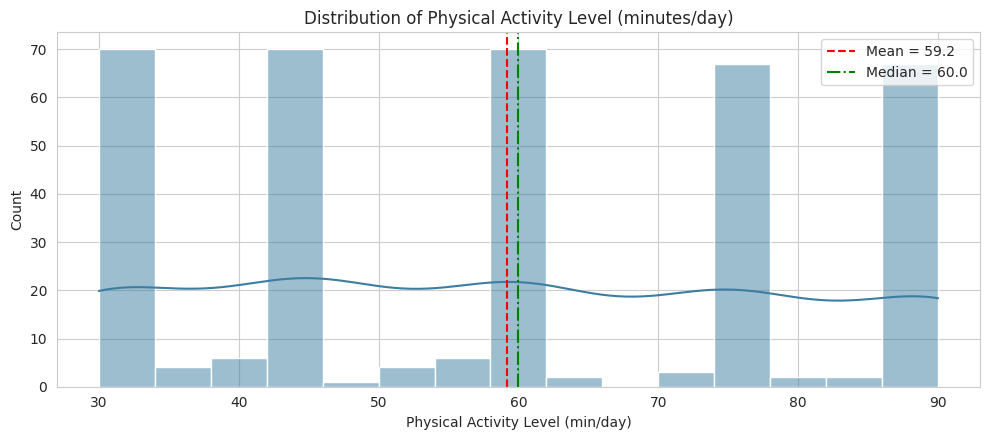

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(df["Physical Activity Level"], bins=15, kde=True, ax=ax, color="#3B7EA1")
ax.set_title("Distribution of Physical Activity Level (minutes/day)")
ax.set_xlabel("Physical Activity Level (min/day)")
ax.set_ylabel("Count")
ax.axvline(df["Physical Activity Level"].mean(), color="red", linestyle="--",
           label=f"Mean = {df['Physical Activity Level'].mean():.1f}")
ax.axvline(df["Physical Activity Level"].median(), color="green", linestyle="-.",
           label=f"Median = {df['Physical Activity Level'].median():.1f}")
ax.legend()
fig.tight_layout()
plt.show()

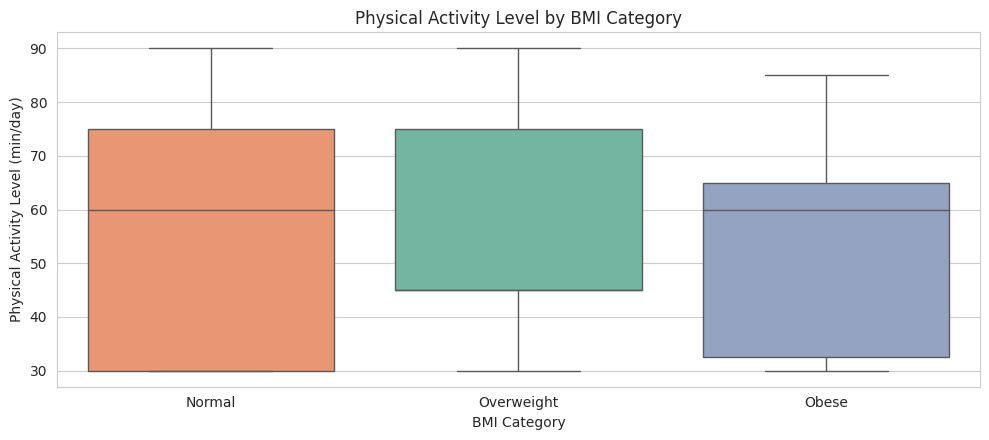

BMI Category
Normal           60.0
Normal Weight    60.0
Obese            60.0
Overweight       45.0
Name: Physical Activity Level, dtype: float64


In [16]:
order = ["Normal", "Overweight", "Obese"]
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=df, x="BMI Category", y="Physical Activity Level", order=order, ax=ax, hue="BMI Category",
            palette="Set2", legend=False)
ax.set_title("Physical Activity Level by BMI Category")
ax.set_ylabel("Physical Activity Level (min/day)")
fig.tight_layout()
plt.show()
print(df.groupby("BMI Category")["Physical Activity Level"].median())

**Findings:**

- Typical (median) physical activity is **60 minutes/day** — the histogram shows a bimodal-ish shape with a large cluster around 60–70 min and a smaller cluster around 30–45 min, rather than one clean bell curve.
- Skewness is close to zero (0.074), so the distribution isn't meaningfully lopsided — the two clusters roughly balance out.
- The BMI Category box plot shows the **Overweight** group has a lower median activity level (45 min) than **Normal** and **Obese** (both 60 min). I'm reporting this as observed— with the duplication issue found in Section 1, and Obese being the smallest group (n=10 after cleaning), this comparison is on thin ice and shouldn't be over-interpreted as a real physiological pattern.

## 3. Number of Daily Steps

**Tool choice:** histogram for the overall distribution shape, box plot by Occupation (top 6 by sample size) since daily steps plausibly differ by job type.

Saved figs/hist_steps.png


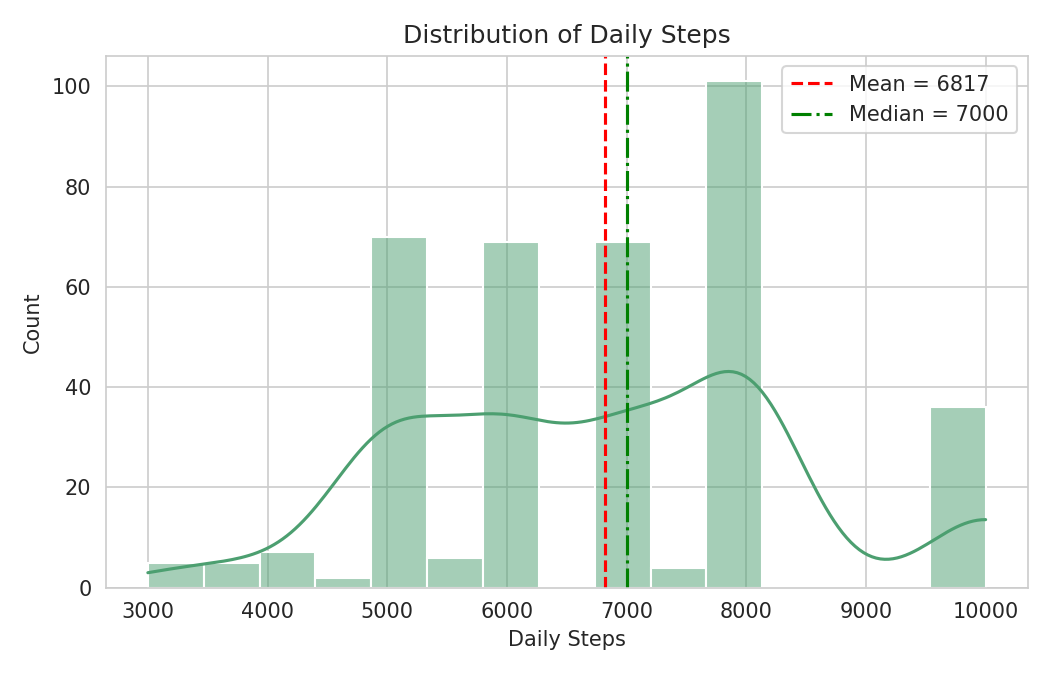

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(df["Daily Steps"], bins=15, kde=True, ax=ax, color="#4C9F70")
ax.set_title("Distribution of Daily Steps")
ax.set_xlabel("Daily Steps")
ax.set_ylabel("Count")
ax.axvline(df["Daily Steps"].mean(), color="red", linestyle="--",
           label=f"Mean = {df['Daily Steps'].mean():.0f}")
ax.axvline(df["Daily Steps"].median(), color="green", linestyle="-.",
           label=f"Median = {df['Daily Steps'].median():.0f}")
ax.legend()
fig.tight_layout()
plt.show()

Saved figs/box_steps.png


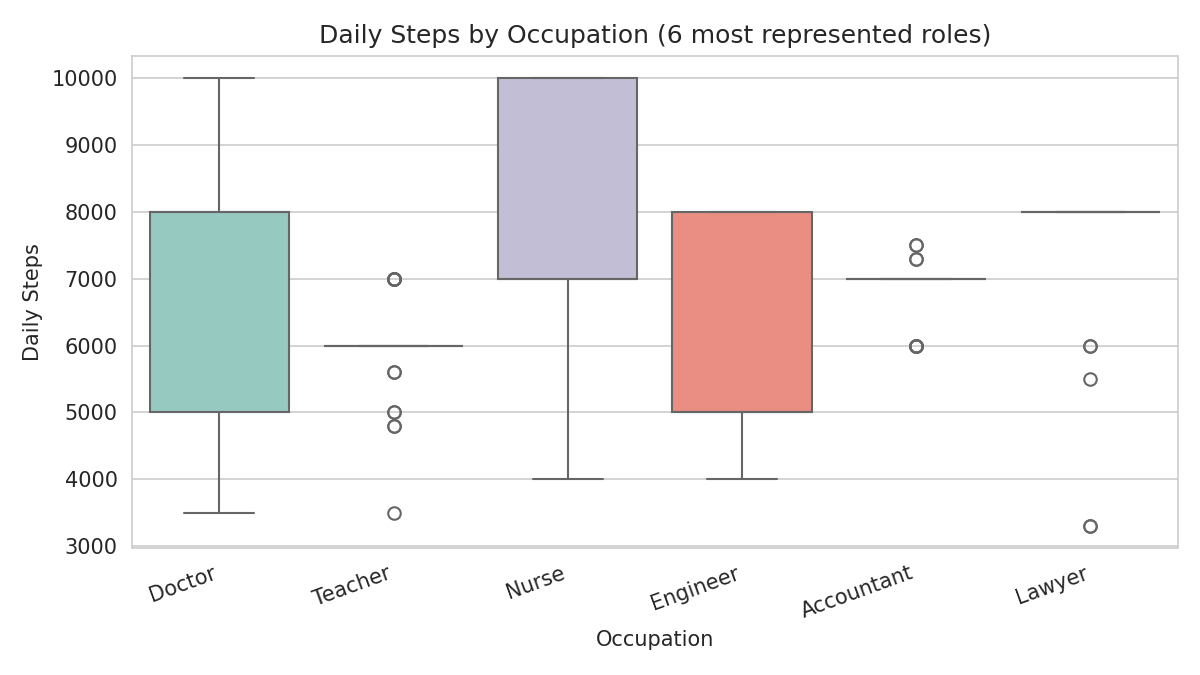

In [8]:
top_occ = df["Occupation"].value_counts().head(6).index
sub = df[df["Occupation"].isin(top_occ)]
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=sub, x="Occupation", y="Daily Steps", ax=ax, hue="Occupation", palette="Set3", legend=False)
ax.set_title("Daily Steps by Occupation (6 most represented roles)")
ax.set_ylabel("Daily Steps")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
plt.show()

**Findings:**

- Typical daily step count is **~7,000 steps (median)**, mean is close at 6,817 — skew is mild (0.178), so either summary is defensible; median is used on the slide as it's the more conventional benchmark against the well-known "10,000 steps/day" reference point.
- Spread is wide (std ≈ 1,618; range 3,000–10,000), so "typical" should be presented with a range, not a single number, so that overstates precision the data doesn't happened.
- The occupation box plot exists mainly to show variation exists across roles — with several occupations having very small sample sizes (e.g. only 4 Software Engineers, 2 Sales Representatives, 1 Manager in the full dataset, per the counts in Section 1), it will be bias to state certain occupation X takes more steps than Y. The safer, defensible claim is that daily step counts vary meaningfully across occupational groups, not a ranked league table of which job is "healthiest."

## 4. Distribution of Heart Rates

**Tool choice:** histogram to show the right-skew directly, box plot by Sleep Disorder status since Heart Rate's skew is the most clinically explainable variable in this dataset and disorder status is the natural grouping to test that against.

Saved figs/hist_hr.png
Skewness: 1.225


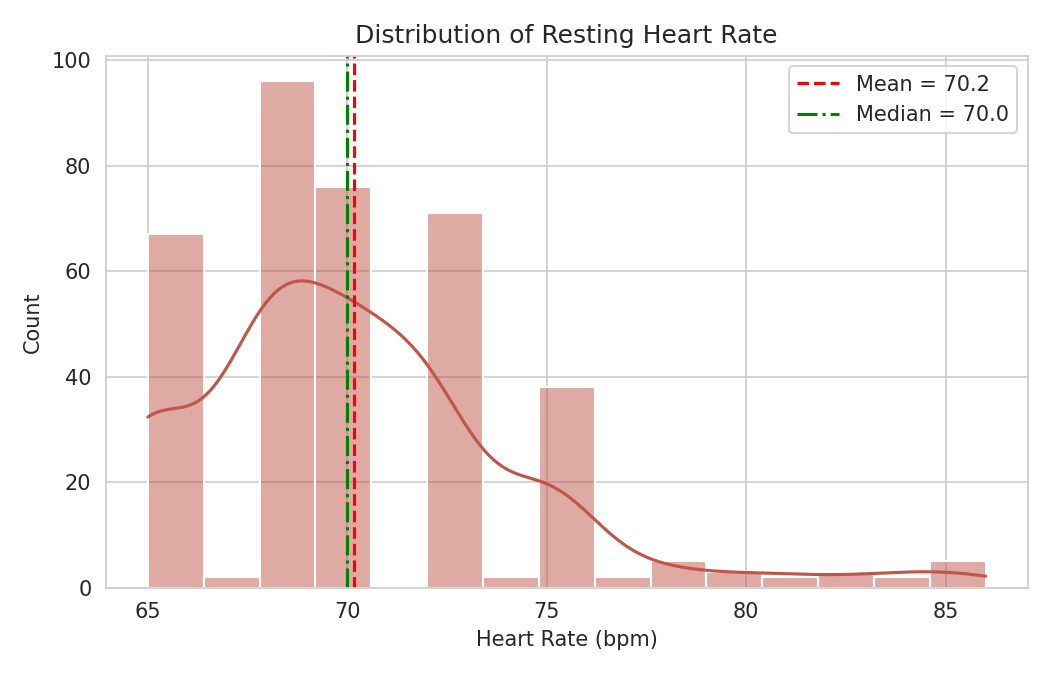

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(df["Heart Rate"], bins=15, kde=True, ax=ax, color="#C1554A")
ax.set_title("Distribution of Resting Heart Rate")
ax.set_xlabel("Heart Rate (bpm)")
ax.set_ylabel("Count")
ax.axvline(df["Heart Rate"].mean(), color="red", linestyle="--",
           label=f"Mean = {df['Heart Rate'].mean():.1f}")
ax.axvline(df["Heart Rate"].median(), color="green", linestyle="-.",
           label=f"Median = {df['Heart Rate'].median():.1f}")
ax.legend()
fig.tight_layout()
plt.show()
print(f"Skewness: {df['Heart Rate'].skew():.3f}")

Saved figs/box_hr.png
                     mean  median       std
Sleep Disorder                             
Insomnia        70.467532    72.0  4.948643
None            69.018265    70.0  2.657797
Sleep Apnea     73.089744    75.0  5.117289


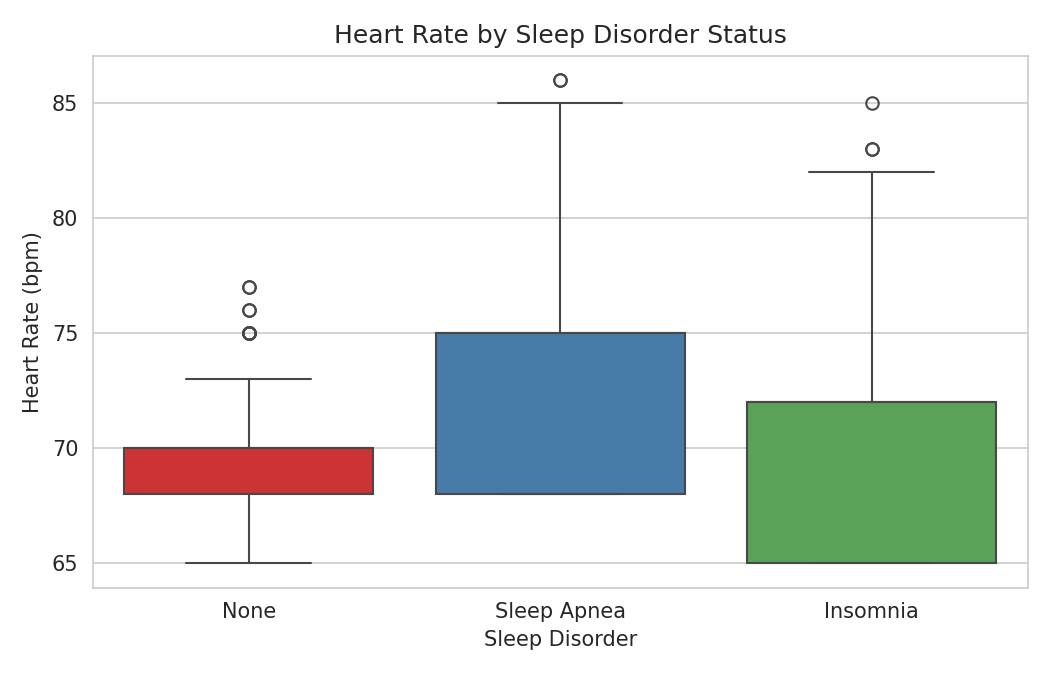

In [10]:
tmp = df.copy()
tmp["Sleep Disorder"] = tmp["Sleep Disorder"].fillna("None")
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=tmp, x="Sleep Disorder", y="Heart Rate", ax=ax, hue="Sleep Disorder", palette="Set1", legend=False)
ax.set_title("Heart Rate by Sleep Disorder Status")
ax.set_ylabel("Heart Rate (bpm)")
fig.tight_layout()
plt.show()
print(tmp.groupby("Sleep Disorder")["Heart Rate"].agg(["mean", "median", "std"]))

**Findings:**

- Heart Rate is the **most skewed variable in this dataset (skew = 1.225, right-skewed)** — most people cluster in the low-to-mid 60s–70s bpm, with a long tail of higher readings.
- **Because it's skewed, the median (70 bpm) is the correct "typical" value to headline** — quoting the mean (70.17) will looks like the distribution were symmetric, even though the two happen to be numerically close here; the shape, not the coincidence of similar values, is what should drive the choice.
- The box plot confirms *why* it's skewed: **Sleep Apnea (median 75 bpm) and Insomnia (median 72 bpm) groups both run higher than the no-disorder group (median 70 bpm)**. This is a real, medically plausible pattern (sleep apnea is independently associated with elevated resting heart rate) and is the strongest, most defensible finding in this whole analysis.

## 5. Summary

1. **64.7% of rows are duplicated lifestyle profiles** (only ~132 distinct combinations across 374 IDs).
2. **Heart Rate is the only meaningfully skewed variable**.
3. **Small-n subgroups exist** (Obese n=10, several occupations n≤4) — any subgroup comparison can only be directional/exploratory, not a confident ranking.
4. **`BMI Category` had two labels for the same class** (`Normal` / `Normal Weight`) — merged both as normal.